In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

In [3]:
df = ratings.merge(movies, on='movieId')

df = df[df['genres'] != '(no genres listed)']

df['reward'] = df['rating'].apply(lambda rating: 1 if rating >= 4 else 0)

df['genre_list'] = df['genres'].apply(lambda x: x.split('|'))

df.head()

,userId,movieId,rating,timestamp,title,genres,reward,genre_list
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama,1,"[Crime, Drama]"
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi,0,"[Drama, Sci-Fi]"
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,1,"[Mystery, Sci-Fi, Thriller]"
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1,"[Mystery, Thriller]"
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1,"[Crime, Mystery, Thriller]"


In [4]:
all_genres = set()

for genre_list in df['genre_list']:
    for genre in genre_list:
        all_genres.add(genre)

genres = sorted(list(all_genres))
d = len(genres)

print(genres)
print(d)

['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
19


In [5]:
movie_stats = df.groupby(['movieId', 'title', 'genres']).agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

movie_stats = movie_stats[movie_stats['rating_count'] >= 10]

movie_stats.head()

,movieId,title,genres,avg_rating,rating_count
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.907328,232
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.353261,92
2,3,Grumpier Old Men (1995),Comedy|Romance,3.189655,58
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.818182,11
4,5,Father of the Bride Part II (1995),Comedy,3.250000,62


# UCB Algorithm

In [6]:
numbers_of_selections = {genre: 0 for genre in genres}
sums_of_rewards = {genre: 0 for genre in genres}

genres_selected = []
rewards = []

for n, row in enumerate(df.itertuples(), start=1):

    selected_genre = None
    max_upper_bound = -1

    for genre in genres:

        if numbers_of_selections[genre] > 0:
            average_reward = sums_of_rewards[genre] / numbers_of_selections[genre]

            delta = math.sqrt(
                (3 / 2) * math.log(n + 1) / numbers_of_selections[genre]
            )

            upper_bound = average_reward + delta

        else:
            upper_bound = float('inf')

        if upper_bound > max_upper_bound:
            max_upper_bound = upper_bound
            selected_genre = genre

    if selected_genre in row.genre_list:
        reward = row.reward
    else:
        reward = 0

    numbers_of_selections[selected_genre] += 1
    sums_of_rewards[selected_genre] += reward

    genres_selected.append(selected_genre)
    rewards.append(reward)

In [7]:
total_reward = sum(rewards)

print("Total Reward:", total_reward)

Total Reward: 23989


In [8]:
ucb_results = pd.DataFrame({
    'genre': genres,
    'selection_count': [numbers_of_selections[g] for g in genres],
    'total_reward': [sums_of_rewards[g] for g in genres]
})

ucb_results['average_reward'] = (
    ucb_results['total_reward'] / ucb_results['selection_count']
)

ucb_results.sort_values(by='average_reward', ascending=False)

,genre,selection_count,total_reward,average_reward
7,Drama,81630,19980,0.244763
4,Comedy,10646,2331,0.218955
0,Action,4590,908,0.197821
16,Thriller,2325,402,0.172903
1,Adventure,1326,192,0.144796
14,Romance,551,45,0.081670
15,Sci-Fi,515,39,0.075728
5,Crime,479,33,0.068894
8,Fantasy,385,18,0.046753
13,Mystery,324,9,0.027778


# Genre Selection Histogram

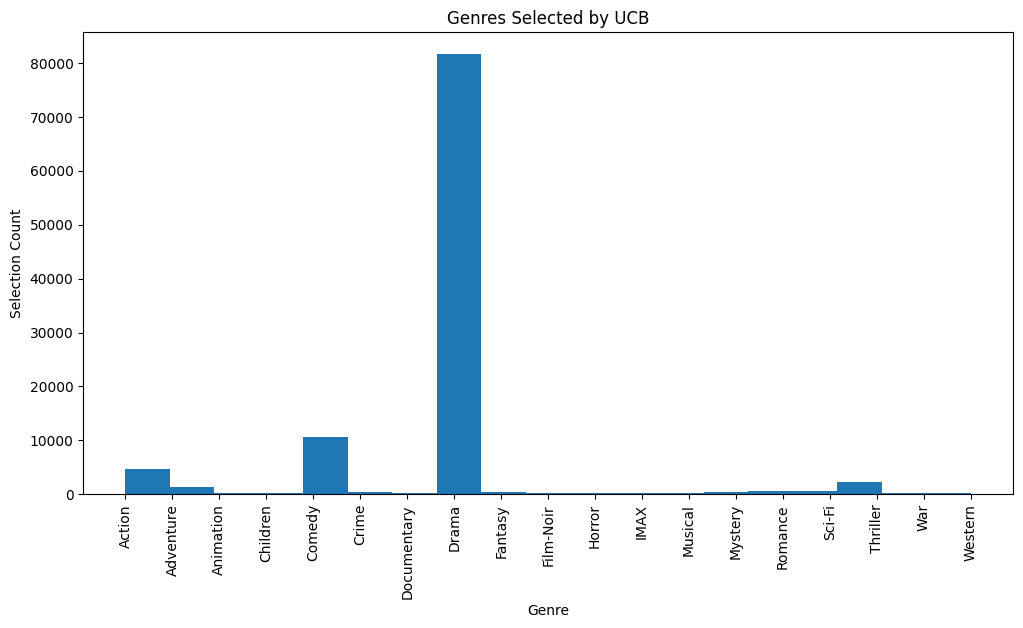

In [9]:
plt.figure(figsize=(12, 6))
plt.hist(genres_selected, bins=len(genres))
plt.xticks(rotation=90)
plt.title('Genres Selected by UCB')
plt.xlabel('Genre')
plt.ylabel('Selection Count')
plt.show()

# Cumulative Reward

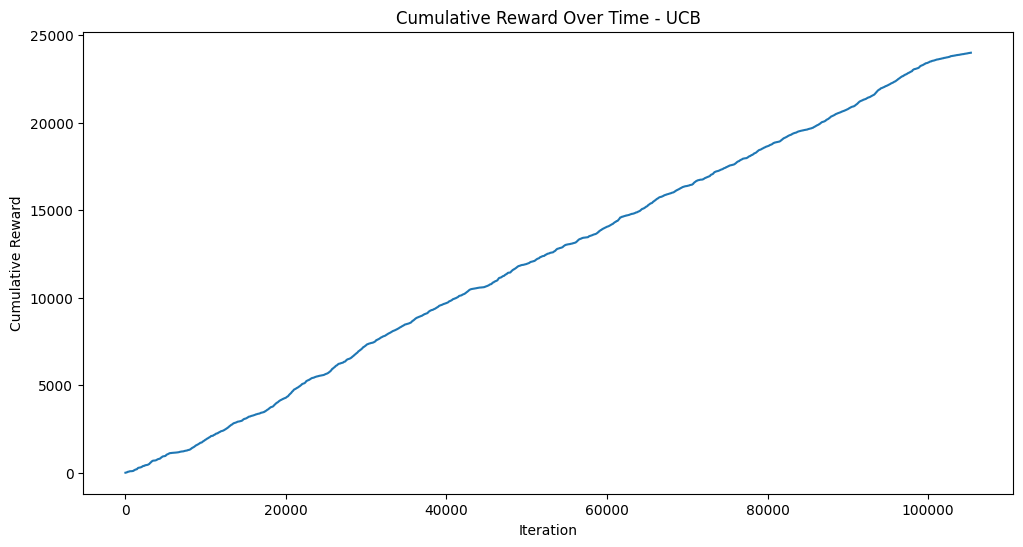

In [10]:
cumulative_rewards = np.cumsum(rewards)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_rewards)
plt.title('Cumulative Reward Over Time - UCB')
plt.xlabel('Iteration')
plt.ylabel('Cumulative Reward')
plt.show()

# Best Genre

In [11]:
best_genre = ucb_results.sort_values(
    by='average_reward',
    ascending=False
).iloc[0]['genre']

print("Best Genre:", best_genre)

Best Genre: Drama


# Movie Recommendation

In [12]:
recommended_movies = movie_stats[
    movie_stats['genres'].apply(
        lambda x: best_genre in x.split('|')
    )
]

recommended_movies = recommended_movies.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=False
)

recommended_movies.head(10)

,movieId,title,genres,avg_rating,rating_count
943,1178,Paths of Glory (1957),Drama|War,4.500000,19
1496,1927,All Quiet on the Western Front (1930),Action|Drama|War,4.500000,13
1372,1730,Kundun (1997),Drama,4.500000,10
5172,7099,Nausicaä of the Valley of the Wind (Kaze no ta...,Adventure|Animation|Drama|Fantasy|Sci-Fi,4.477273,22
938,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,4.459459,37
279,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.454545,308
8042,66934,Dr. Horrible's Sing-Along Blog (2008),Comedy|Drama|Musical|Sci-Fi,4.434783,23
1515,1949,"Man for All Seasons, A (1966)",Drama,4.409091,11
978,1217,Ran (1985),Drama|War,4.403226,31
185,213,Burnt by the Sun (Utomlyonnye solntsem) (1994),Drama,4.400000,10
